# IT25103708 — Feature Engineering
Technique: Final Feature Matrix Assembly + Target Encoding

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv("../data/raw/HAM10000_metadata.csv")

print(df.shape)
df.info()
df.head()

(10015, 7)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10015 entries, 0 to 10014
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   lesion_id     10015 non-null  object 
 1   image_id      10015 non-null  object 
 2   dx            10015 non-null  object 
 3   dx_type       10015 non-null  object 
 4   age           9958 non-null   float64
 5   sex           10015 non-null  object 
 6   localization  10015 non-null  object 
dtypes: float64(1), object(6)
memory usage: 547.8+ KB


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [2]:
df['age'] = df['age'].fillna(df['age'].median())

# Outlier capping
Q1, Q3 = df['age'].quantile(0.25), df['age'].quantile(0.75)
IQR = Q3 - Q1
df['age'] = df['age'].clip(Q1 - 1.5*IQR, Q3 + 1.5*IQR)

# Scaling
scaler = StandardScaler()
df['age_scaled'] = scaler.fit_transform(df[['age']])

# Encoding sex and localization
df = pd.get_dummies(df, columns=['sex', 'localization'], prefix=['sex', 'loc'])

## Why This Feature Assembly Step?

- All prior preprocessing steps (missing values, outlier handling, scaling, encoding) produce partial dataframes. Feature engineering's job is to combine them into one final, model-ready X matrix and a properly encoded target y.
- The target dx has 7 classes and needs numeric encoding so models can consume it, while keeping a mapping back to class names for interpretation of results (especially malignant classes: mel, bcc, akiec).
- Irrelevant identifier columns (image_id, lesion_id) are dropped since they carry no predictive signal and would just leak row identity to the model.

In [3]:
le = LabelEncoder()
df['dx_encoded'] = le.fit_transform(df['dx'])

print("Class mapping:")
for i, cls in enumerate(le.classes_):
    print(i, "->", cls)

# Drop identifier / raw columns not used as features
drop_cols = ['lesion_id', 'image_id', 'dx', 'age']  # keep age_scaled, drop raw age
feature_cols = [c for c in df.columns if c not in drop_cols + ['dx_encoded']]

X = df[feature_cols]
y = df['dx_encoded']

print("Final X shape:", X.shape)
print("Final y shape:", y.shape)
X.head()

Class mapping:
0 -> akiec
1 -> bcc
2 -> bkl
3 -> df
4 -> mel
5 -> nv
6 -> vasc
Final X shape: (10015, 20)
Final y shape: (10015,)


,dx_type,age_scaled,sex_female,sex_male,sex_unknown,loc_abdomen,loc_acral,loc_back,loc_chest,loc_ear,loc_face,loc_foot,loc_genital,loc_hand,loc_lower extremity,loc_neck,loc_scalp,loc_trunk,loc_unknown,loc_upper extremity
0,histo,1.665816,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
1,histo,1.665816,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
2,histo,1.665816,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
3,histo,1.665816,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
4,histo,1.369798,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False


C:\Program Files\KMSpico\temp\ipykernel_17052\737348316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df['dx_encoded'], palette='magma')


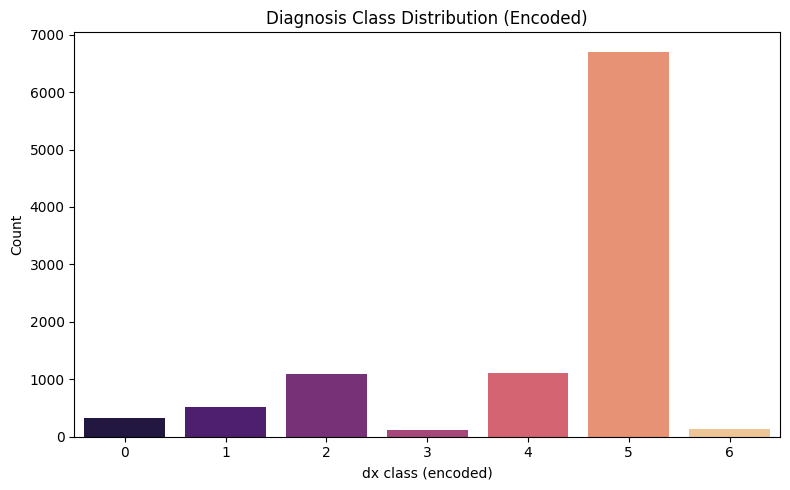

dx_encoded
5    66.949576
4    11.113330
2    10.973540
1     5.132302
0     3.265102
6     1.417873
3     1.148278
Name: proportion, dtype: float64


In [4]:
plt.figure(figsize=(8,5))
sns.countplot(x=df['dx_encoded'], palette='magma')
plt.title('Diagnosis Class Distribution (Encoded)')
plt.xlabel('dx class (encoded)')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../results/eda_visualizations/dx_class_distribution.png', dpi=150)
plt.show()

print(y.value_counts(normalize=True) * 100)

## Interpretation

The class distribution confirms the strong imbalance flagged in the project overview — roughly two-thirds of records fall into the benign nv class, while malignant classes (mel, bcc, akiec) are a small minority.

In [5]:
X.to_csv("../results/outputs/final_features_X.csv", index=False)
y.to_csv("../results/outputs/final_target_y.csv", index=False)